Each week, you will apply the concepts of that week to your Integrated Capstone Project dataset. This notebook focuses on K-nearest neighbors, distance metrics, and how those choices behave differently on the Wisconsin and Brazil cancer datasets.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/jamieconner/projects/bu/dx799_01/mod_c_capstone')

## Imports


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.load_data import load_brazil, load_wisconsin, split_X_y


## Setup

KNN is entirely distance-based, so scaling is required before comparing Euclidean, Manhattan, or Minkowski distance. I use stratified train/test splits and cross-validation to keep class balance stable and to reduce the chance that one lucky split drives the conclusion.


In [3]:
RANDOM_STATE = 42
BRAZIL_SAMPLE_SIZE = 10000
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

BASE_PARAM_GRID = [
    {
        "knn__n_neighbors": [3, 5, 7, 11, 15, 21],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan"],
    },
    {
        "knn__n_neighbors": [3, 5, 7, 11, 15, 21],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["minkowski"],
        "knn__p": [1, 2],
    },
]

SCORING_OPTIONS = {
    "roc_auc": "roc_auc",
    "f1": "f1",
}

pd.set_option("display.max_columns", 100)


In [4]:
def run_knn_experiment(df, target_col, dataset_name, scoring="roc_auc"):
    X, y = split_X_y(df, target_col)
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ])

    search = GridSearchCV(
        estimator=pipe,
        param_grid=BASE_PARAM_GRID,
        scoring=SCORING_OPTIONS[scoring],
        cv=CV,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    results = {
        "dataset": dataset_name,
        "tuning_metric": scoring,
        "best_params": search.best_params_,
        "cv_score": search.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, y_prob),
        "test_pr_auc": average_precision_score(y_test, y_prob),
    }

    cv_results = pd.DataFrame(search.cv_results_).sort_values(
        by="rank_test_score"
    )

    return {
        "results": results,
        "cv_results": cv_results,
        "best_model": best_model,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }


def summarize_distance_results(cv_results, top_n=8):
    cols = [
        "mean_test_score",
        "std_test_score",
        "param_knn__metric",
        "param_knn__p",
        "param_knn__n_neighbors",
        "param_knn__weights",
        "rank_test_score",
    ]
    available_cols = [c for c in cols if c in cv_results.columns]
    return cv_results.loc[:, available_cols].head(top_n)


def plot_top_configs(cv_results, title, top_n=8):
    top = cv_results.head(top_n).copy()
    top["label"] = (
        top["param_knn__metric"].astype(str)
        + " | k="
        + top["param_knn__n_neighbors"].astype(str)
        + " | "
        + top["param_knn__weights"].astype(str)
    )

    plt.figure(figsize=(10, 4.5))
    plt.barh(top["label"], top["mean_test_score"], color="#2c7fb8")
    plt.gca().invert_yaxis()
    plt.xlabel("Mean CV score")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def show_confusion(result, title):
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ConfusionMatrixDisplay.from_predictions(
        result["y_test"],
        result["y_pred"],
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


## Wisconsin dataset

Wisconsin is the cleaner dataset, so it is a good place to check whether KNN can separate the classes after scaling and whether the choice of distance metric makes a meaningful difference.


In [5]:
df_w, target_w = load_wisconsin()
wisconsin_roc = run_knn_experiment(df_w, target_w, "Wisconsin", scoring="roc_auc")
wisconsin_f1 = run_knn_experiment(df_w, target_w, "Wisconsin", scoring="f1")

pd.DataFrame([wisconsin_roc["results"], wisconsin_f1["results"]])


,dataset,tuning_metric,best_params,cv_score,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,Wisconsin,roc_auc,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.989216,0.947368,0.973684,0.880952,0.925,0.982308,0.979353
1,Wisconsin,f1,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.966708,0.964912,1.000000,0.904762,0.950,0.973545,0.965596


In [6]:
summarize_distance_results(wisconsin_roc["cv_results"])


,mean_test_score,std_test_score,param_knn__metric,param_knn__p,param_knn__n_neighbors,param_knn__weights,rank_test_score
39,0.989216,0.010946,minkowski,2.0,11,distance,1
7,0.989216,0.010946,euclidean,NaN,11,distance,1
43,0.989112,0.009601,minkowski,2.0,15,distance,3
9,0.989112,0.009601,euclidean,NaN,15,distance,3
1,0.989009,0.012537,euclidean,NaN,3,distance,5
27,0.989009,0.012537,minkowski,2.0,3,distance,5
47,0.988854,0.009472,minkowski,2.0,21,distance,7
11,0.988854,0.009472,euclidean,NaN,21,distance,7


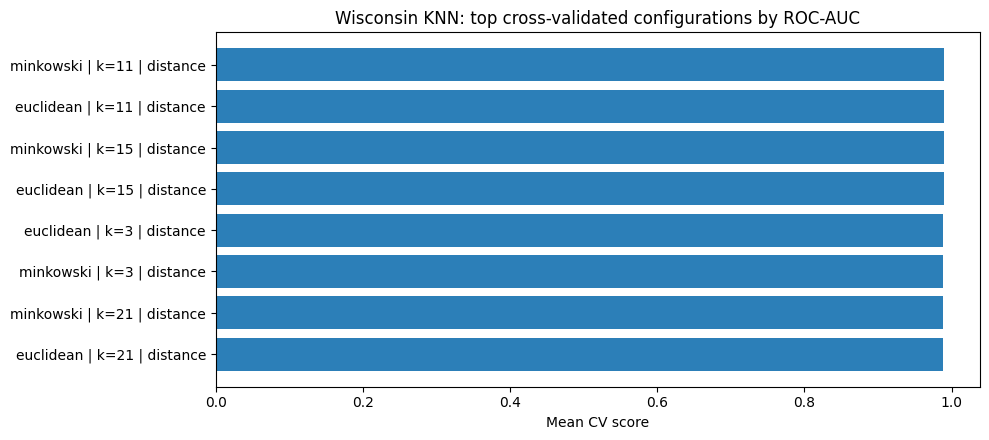

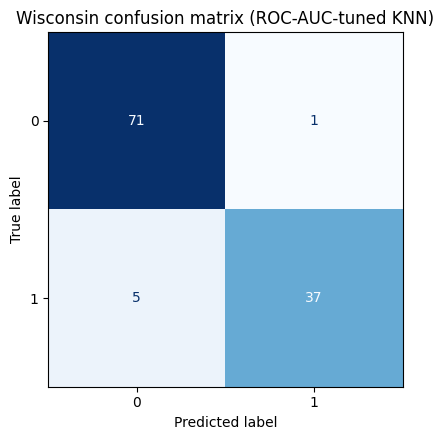

Best ROC-AUC-tuned parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        72
           1       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [7]:
plot_top_configs(
    wisconsin_roc["cv_results"],
    "Wisconsin KNN: top cross-validated configurations by ROC-AUC",
)
show_confusion(wisconsin_roc, "Wisconsin confusion matrix (ROC-AUC-tuned KNN)")

print("Best ROC-AUC-tuned parameters:", wisconsin_roc["results"]["best_params"])
print(classification_report(wisconsin_roc["y_test"], wisconsin_roc["y_pred"], zero_division=0))


Wisconsin should perform strongly because the features are numeric, the dataset is relatively clean, and the classes are fairly separable. If Euclidean and Manhattan end up close, that supports the idea that the signal is strong enough that the metric choice matters less than basic scaling and a reasonable value of `k`.


## Brazil dataset

Brazil is much larger and more imbalanced, so I use a stratified sample to keep KNN computationally feasible. This is still consistent with the milestone goal because the point is to compare how distance-based classification behaves on the harder dataset, especially in terms of recall and precision.


In [8]:
df_b, target_b = load_brazil(sample_size=BRAZIL_SAMPLE_SIZE, random_state=RANDOM_STATE)
brazil_roc = run_knn_experiment(df_b, target_b, "Brazil", scoring="roc_auc")
brazil_f1 = run_knn_experiment(df_b, target_b, "Brazil", scoring="f1")

pd.DataFrame([brazil_roc["results"], brazil_f1["results"]])


,dataset,tuning_metric,best_params,cv_score,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,Brazil,roc_auc,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.909453,0.9385,0.648148,0.251799,0.362694,0.877595,0.440528
1,Brazil,f1,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.490359,0.9380,0.575758,0.410072,0.478992,0.803933,0.384068


In [9]:
summarize_distance_results(brazil_roc["cv_results"])


,mean_test_score,std_test_score,param_knn__metric,param_knn__p,param_knn__n_neighbors,param_knn__weights,rank_test_score
46,0.909453,0.011346,minkowski,2.0,21,uniform,1
10,0.909453,0.011346,euclidean,NaN,21,uniform,1
44,0.907550,0.017167,minkowski,1.0,21,uniform,3
22,0.907550,0.017167,manhattan,NaN,21,uniform,3
47,0.905612,0.006689,minkowski,2.0,21,distance,5
11,0.905612,0.006689,euclidean,NaN,21,distance,5
45,0.903041,0.012209,minkowski,1.0,21,distance,7
23,0.903041,0.012209,manhattan,NaN,21,distance,7


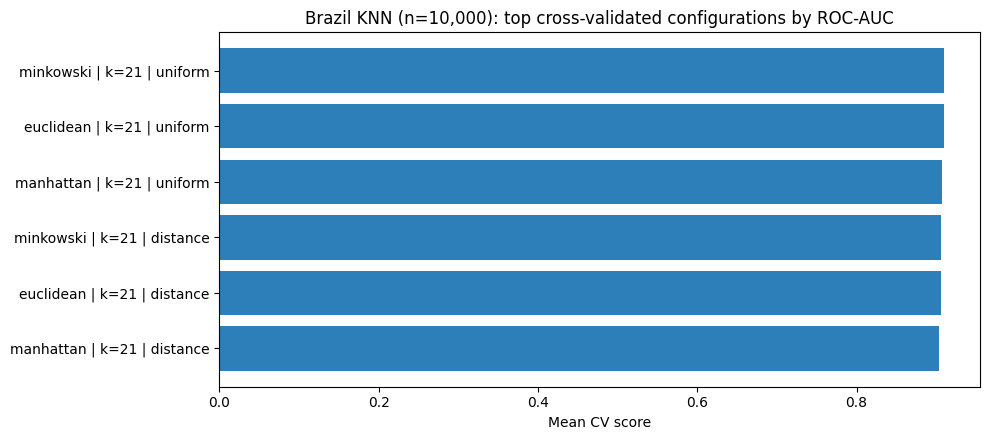

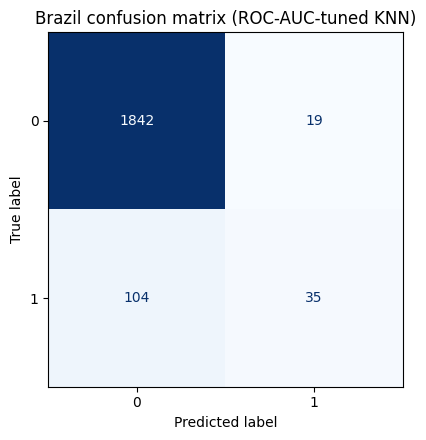

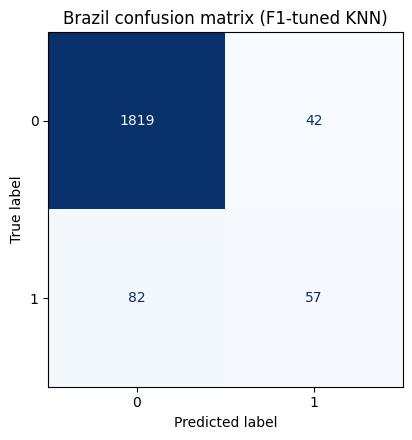

Best ROC-AUC-tuned parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 21, 'knn__weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1861
           1       0.65      0.25      0.36       139

    accuracy                           0.94      2000
   macro avg       0.80      0.62      0.67      2000
weighted avg       0.93      0.94      0.93      2000

Best F1-tuned parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1861
           1       0.58      0.41      0.48       139

    accuracy                           0.94      2000
   macro avg       0.77      0.69      0.72      2000
weighted avg       0.93      0.94      0.93      2000



In [10]:
plot_top_configs(
    brazil_roc["cv_results"],
    f"Brazil KNN (n={BRAZIL_SAMPLE_SIZE:,}): top cross-validated configurations by ROC-AUC",
)
show_confusion(brazil_roc, "Brazil confusion matrix (ROC-AUC-tuned KNN)")
show_confusion(brazil_f1, "Brazil confusion matrix (F1-tuned KNN)")

print("Best ROC-AUC-tuned parameters:", brazil_roc["results"]["best_params"])
print(classification_report(brazil_roc["y_test"], brazil_roc["y_pred"], zero_division=0))
print("Best F1-tuned parameters:", brazil_f1["results"]["best_params"])
print(classification_report(brazil_f1["y_test"], brazil_f1["y_pred"], zero_division=0))


Brazil is the more informative KNN result for the capstone because accuracy alone can look high even when recall is still weak. A ROC-AUC-tuned model may rank cases well but miss too many positive cases at the default threshold, while an F1-tuned model usually trades some ranking quality for better balance between precision and recall.


## Cross-dataset comparison


In [11]:
comparison = pd.DataFrame([
    wisconsin_roc["results"],
    wisconsin_f1["results"],
    brazil_roc["results"],
    brazil_f1["results"]
]).drop(columns=["best_params"])
comparison


,dataset,tuning_metric,cv_score,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,Wisconsin,roc_auc,0.989216,0.947368,0.973684,0.880952,0.925000,0.982308,0.979353
1,Wisconsin,f1,0.966708,0.964912,1.000000,0.904762,0.950000,0.973545,0.965596
2,Brazil,roc_auc,0.909453,0.938500,0.648148,0.251799,0.362694,0.877595,0.440528
3,Brazil,f1,0.490359,0.938000,0.575758,0.410072,0.478992,0.803933,0.384068


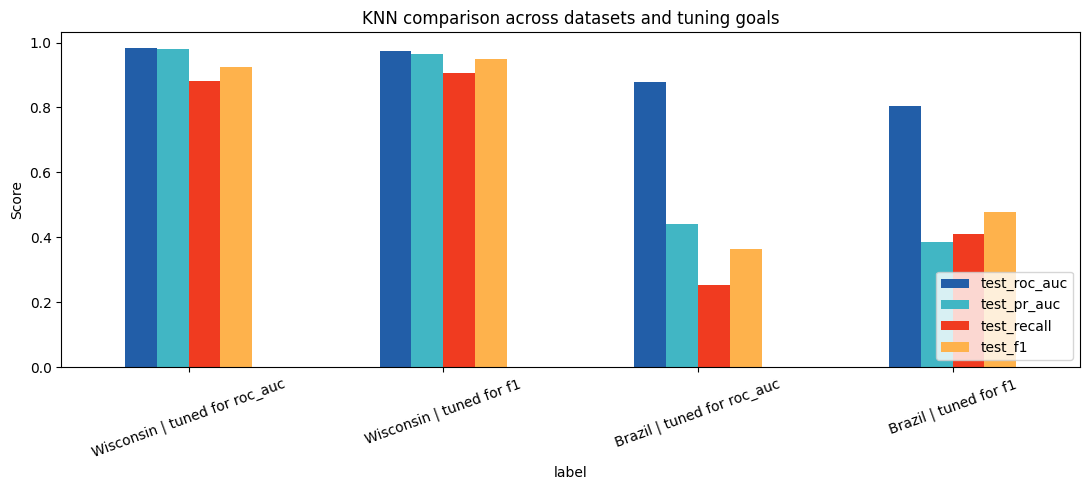

In [12]:
plot_df = comparison[[
    "dataset",
    "tuning_metric",
    "test_roc_auc",
    "test_pr_auc",
    "test_recall",
    "test_f1"
]].copy()
plot_df["label"] = plot_df["dataset"] + " | tuned for " + plot_df["tuning_metric"]
plot_df = plot_df.set_index("label")

ax = plot_df[["test_roc_auc", "test_pr_auc", "test_recall", "test_f1"]].plot(
    kind="bar",
    figsize=(11, 5),
    rot=20,
    color=["#225ea8", "#41b6c4", "#f03b20", "#feb24c"]
)
ax.set_ylabel("Score")
ax.set_title("KNN comparison across datasets and tuning goals")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [13]:
# Report both ROC-AUC and PR-AUC CV performance for the selected KNN models.
# This refits only the winning pipelines; it does not repeat either grid search.
from sklearn.model_selection import cross_validate

knn_cv_scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

X_w_all, y_w_all = split_X_y(df_w, target_w)
X_w_train, _, y_w_train, _ = train_test_split(
    X_w_all,
    y_w_all,
    test_size=0.2,
    stratify=y_w_all,
    random_state=RANDOM_STATE,
)
X_b_all, y_b_all = split_X_y(df_b, target_b)
X_b_train, _, y_b_train, _ = train_test_split(
    X_b_all,
    y_b_all,
    test_size=0.2,
    stratify=y_b_all,
    random_state=RANDOM_STATE,
)

wisconsin_knn_cv = cross_validate(
    wisconsin_roc["best_model"],
    X_w_train,
    y_w_train,
    cv=CV,
    scoring=knn_cv_scoring,
    n_jobs=1,
)
brazil_knn_cv = cross_validate(
    brazil_roc["best_model"],
    X_b_train,
    y_b_train,
    cv=CV,
    scoring=knn_cv_scoring,
    n_jobs=1,
)

knn_cv_results_df = pd.DataFrame(
    [
        {
            "dataset": "Wisconsin",
            "model": "KNN",
            "cv_folds": 5,
            "cv_roc_auc_mean": wisconsin_knn_cv["test_roc_auc"].mean(),
            "cv_roc_auc_sd": wisconsin_knn_cv["test_roc_auc"].std(),
            "cv_pr_auc_mean": wisconsin_knn_cv["test_average_precision"].mean(),
            "cv_pr_auc_sd": wisconsin_knn_cv["test_average_precision"].std(),
        },
        {
            "dataset": "Brazil",
            "model": "KNN",
            "cv_folds": 5,
            "cv_roc_auc_mean": brazil_knn_cv["test_roc_auc"].mean(),
            "cv_roc_auc_sd": brazil_knn_cv["test_roc_auc"].std(),
            "cv_pr_auc_mean": brazil_knn_cv["test_average_precision"].mean(),
            "cv_pr_auc_sd": brazil_knn_cv["test_average_precision"].std(),
        },
    ]
)

print(knn_cv_results_df.round(4).to_string(index=False))


  dataset model  cv_folds  cv_roc_auc_mean  cv_roc_auc_sd  cv_pr_auc_mean  cv_pr_auc_sd
Wisconsin   KNN         5           0.9892         0.0109          0.9875        0.0121
   Brazil   KNN         5           0.9094         0.0113          0.5165        0.0429


## Conclusions

KNN worked well on Wisconsin after scaling, which is what I expected from a cleaner and more separable dataset. Brazil was harder: the model could still produce useful ranking performance, but the default classification behavior showed why recall, F1, and PR-AUC matter more than accuracy alone on an imbalanced outcome problem.

For the Milestone 2 writeup, the most defensible KNN discussion is:

- Overfitting was controlled with scaling, train/test separation, stratified cross-validation, and tuning `k` instead of using a very small neighborhood by default.
- Distance metric choice mattered somewhat, but the larger lesson was that dataset structure mattered more: Wisconsin was easy for KNN, while Brazil exposed the precision-recall tradeoff.
- EDA mattered because KNN depends directly on distance, so feature scale and class imbalance were both central to model behavior.
